Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 121MB/s] 


Finalizing MobileNetV3-L for 9 classes...
Epoch 01 | Val Acc: 89.56% | Val Loss: 0.6730 | Time: 123s
Epoch 02 | Val Acc: 93.78% | Val Loss: 0.2987 | Time: 12s
Epoch 03 | Val Acc: 93.78% | Val Loss: 0.3136 | Time: 12s
Epoch 04 | Val Acc: 93.11% | Val Loss: 0.3280 | Time: 12s
Epoch 05 | Val Acc: 92.44% | Val Loss: 0.5799 | Time: 12s
Epoch 06 | Val Acc: 97.78% | Val Loss: 0.1667 | Time: 13s
Epoch 07 | Val Acc: 97.78% | Val Loss: 0.2052 | Time: 12s
Epoch 08 | Val Acc: 97.78% | Val Loss: 0.2327 | Time: 12s
Epoch 09 | Val Acc: 97.78% | Val Loss: 0.1132 | Time: 12s
Epoch 10 | Val Acc: 97.33% | Val Loss: 0.1922 | Time: 12s
Epoch 11 | Val Acc: 96.89% | Val Loss: 0.2181 | Time: 12s
Epoch 12 | Val Acc: 97.56% | Val Loss: 0.1876 | Time: 12s
Epoch 13 | Val Acc: 97.78% | Val Loss: 0.2018 | Time: 12s
Epoch 14 | Val Acc: 98.00% | Val Loss: 0.1866 | Time: 12s
Early stopping triggered.
All research artifacts saved to /kaggle/working/


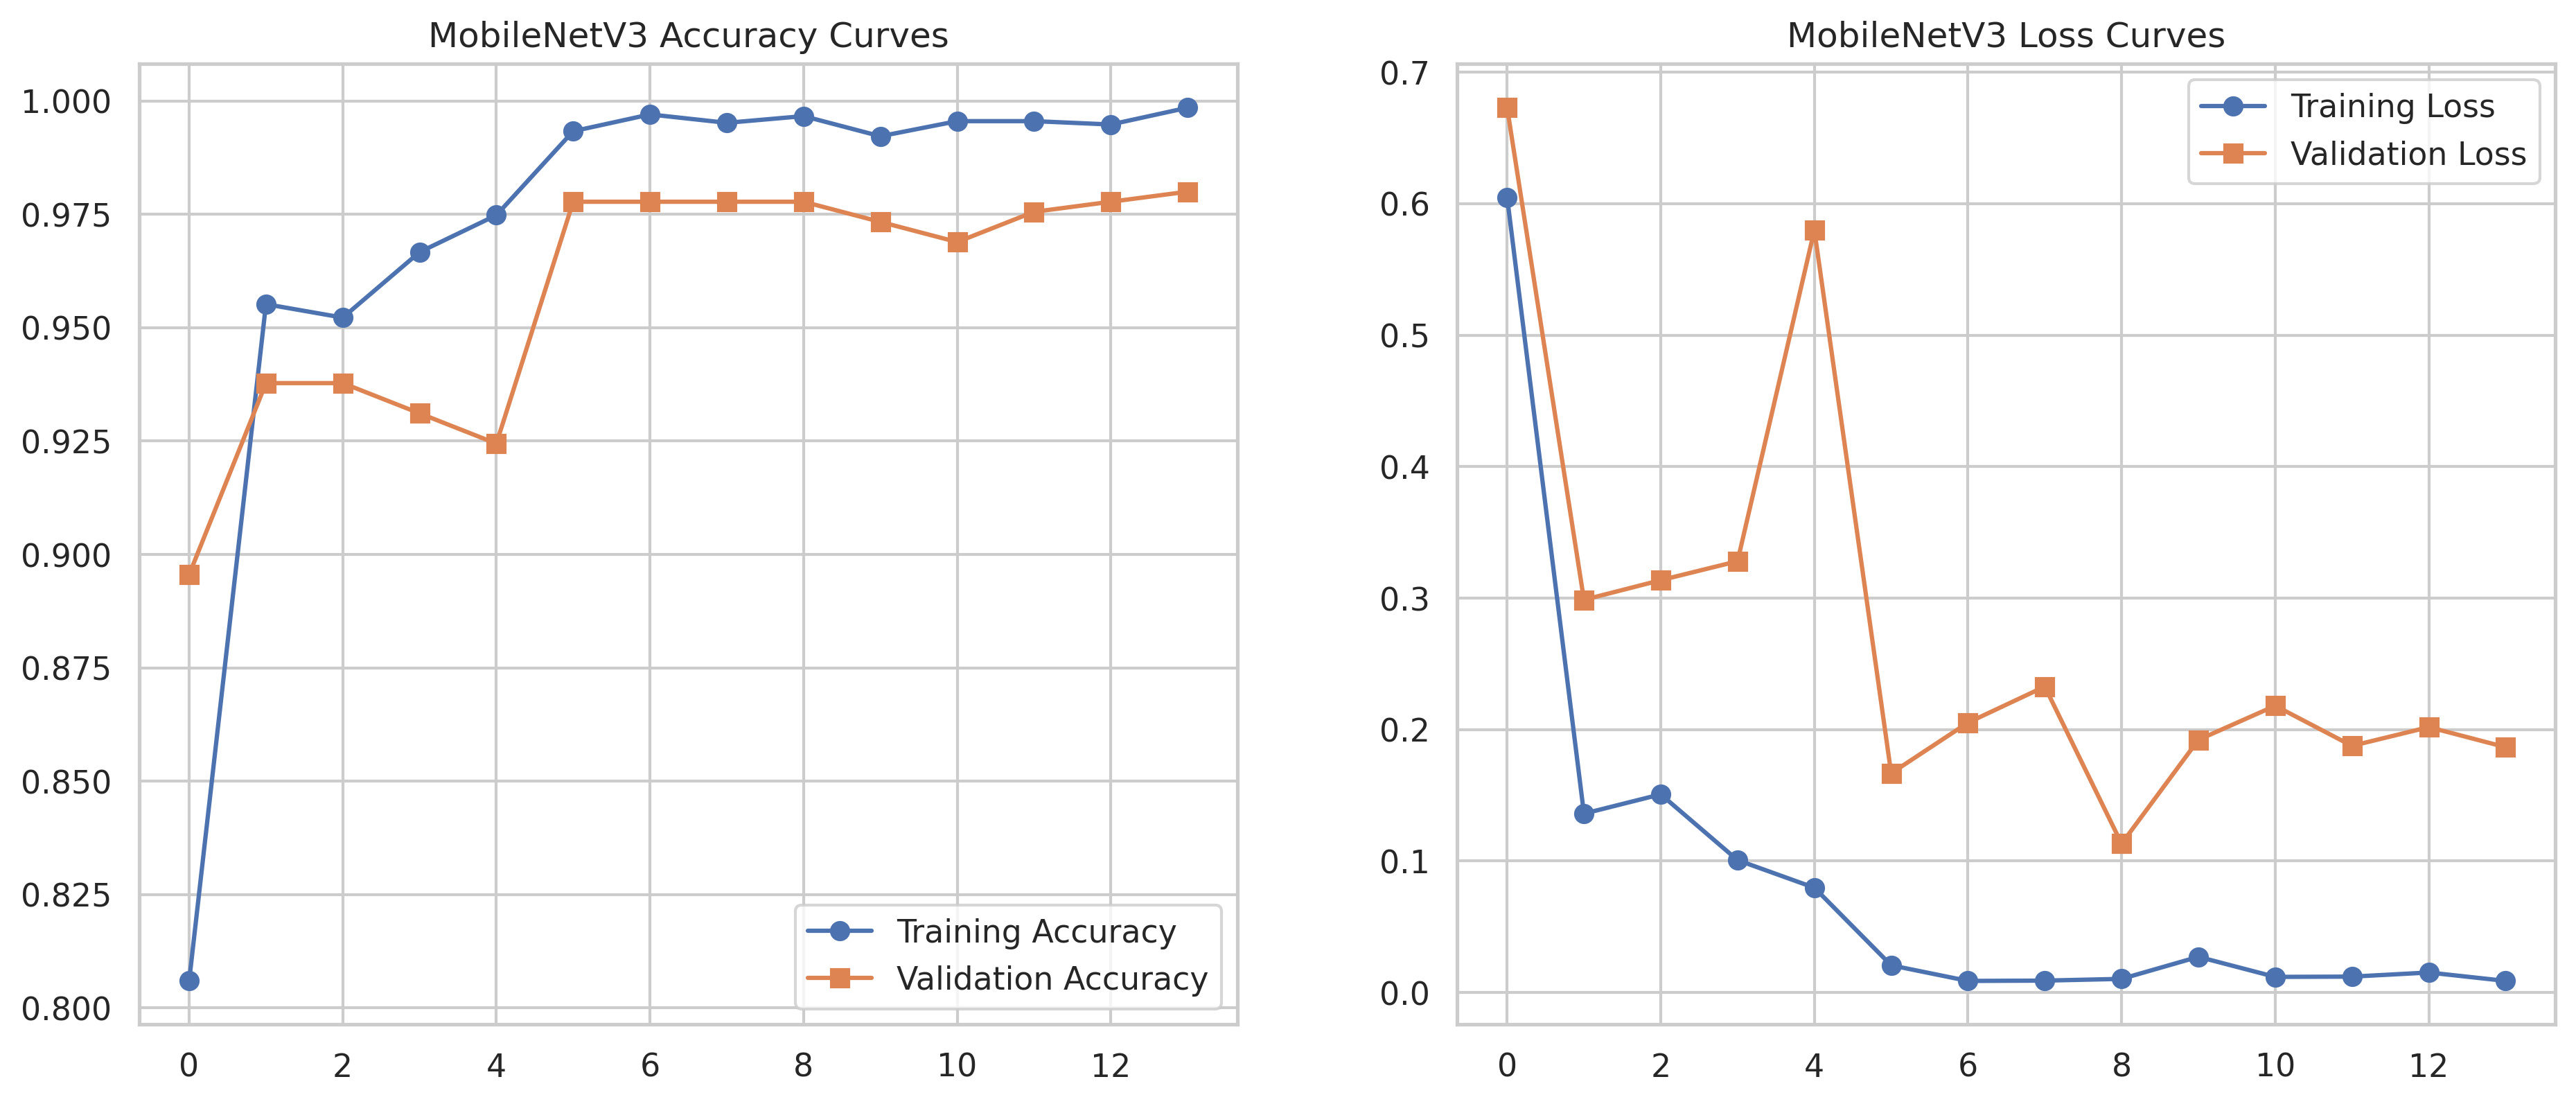

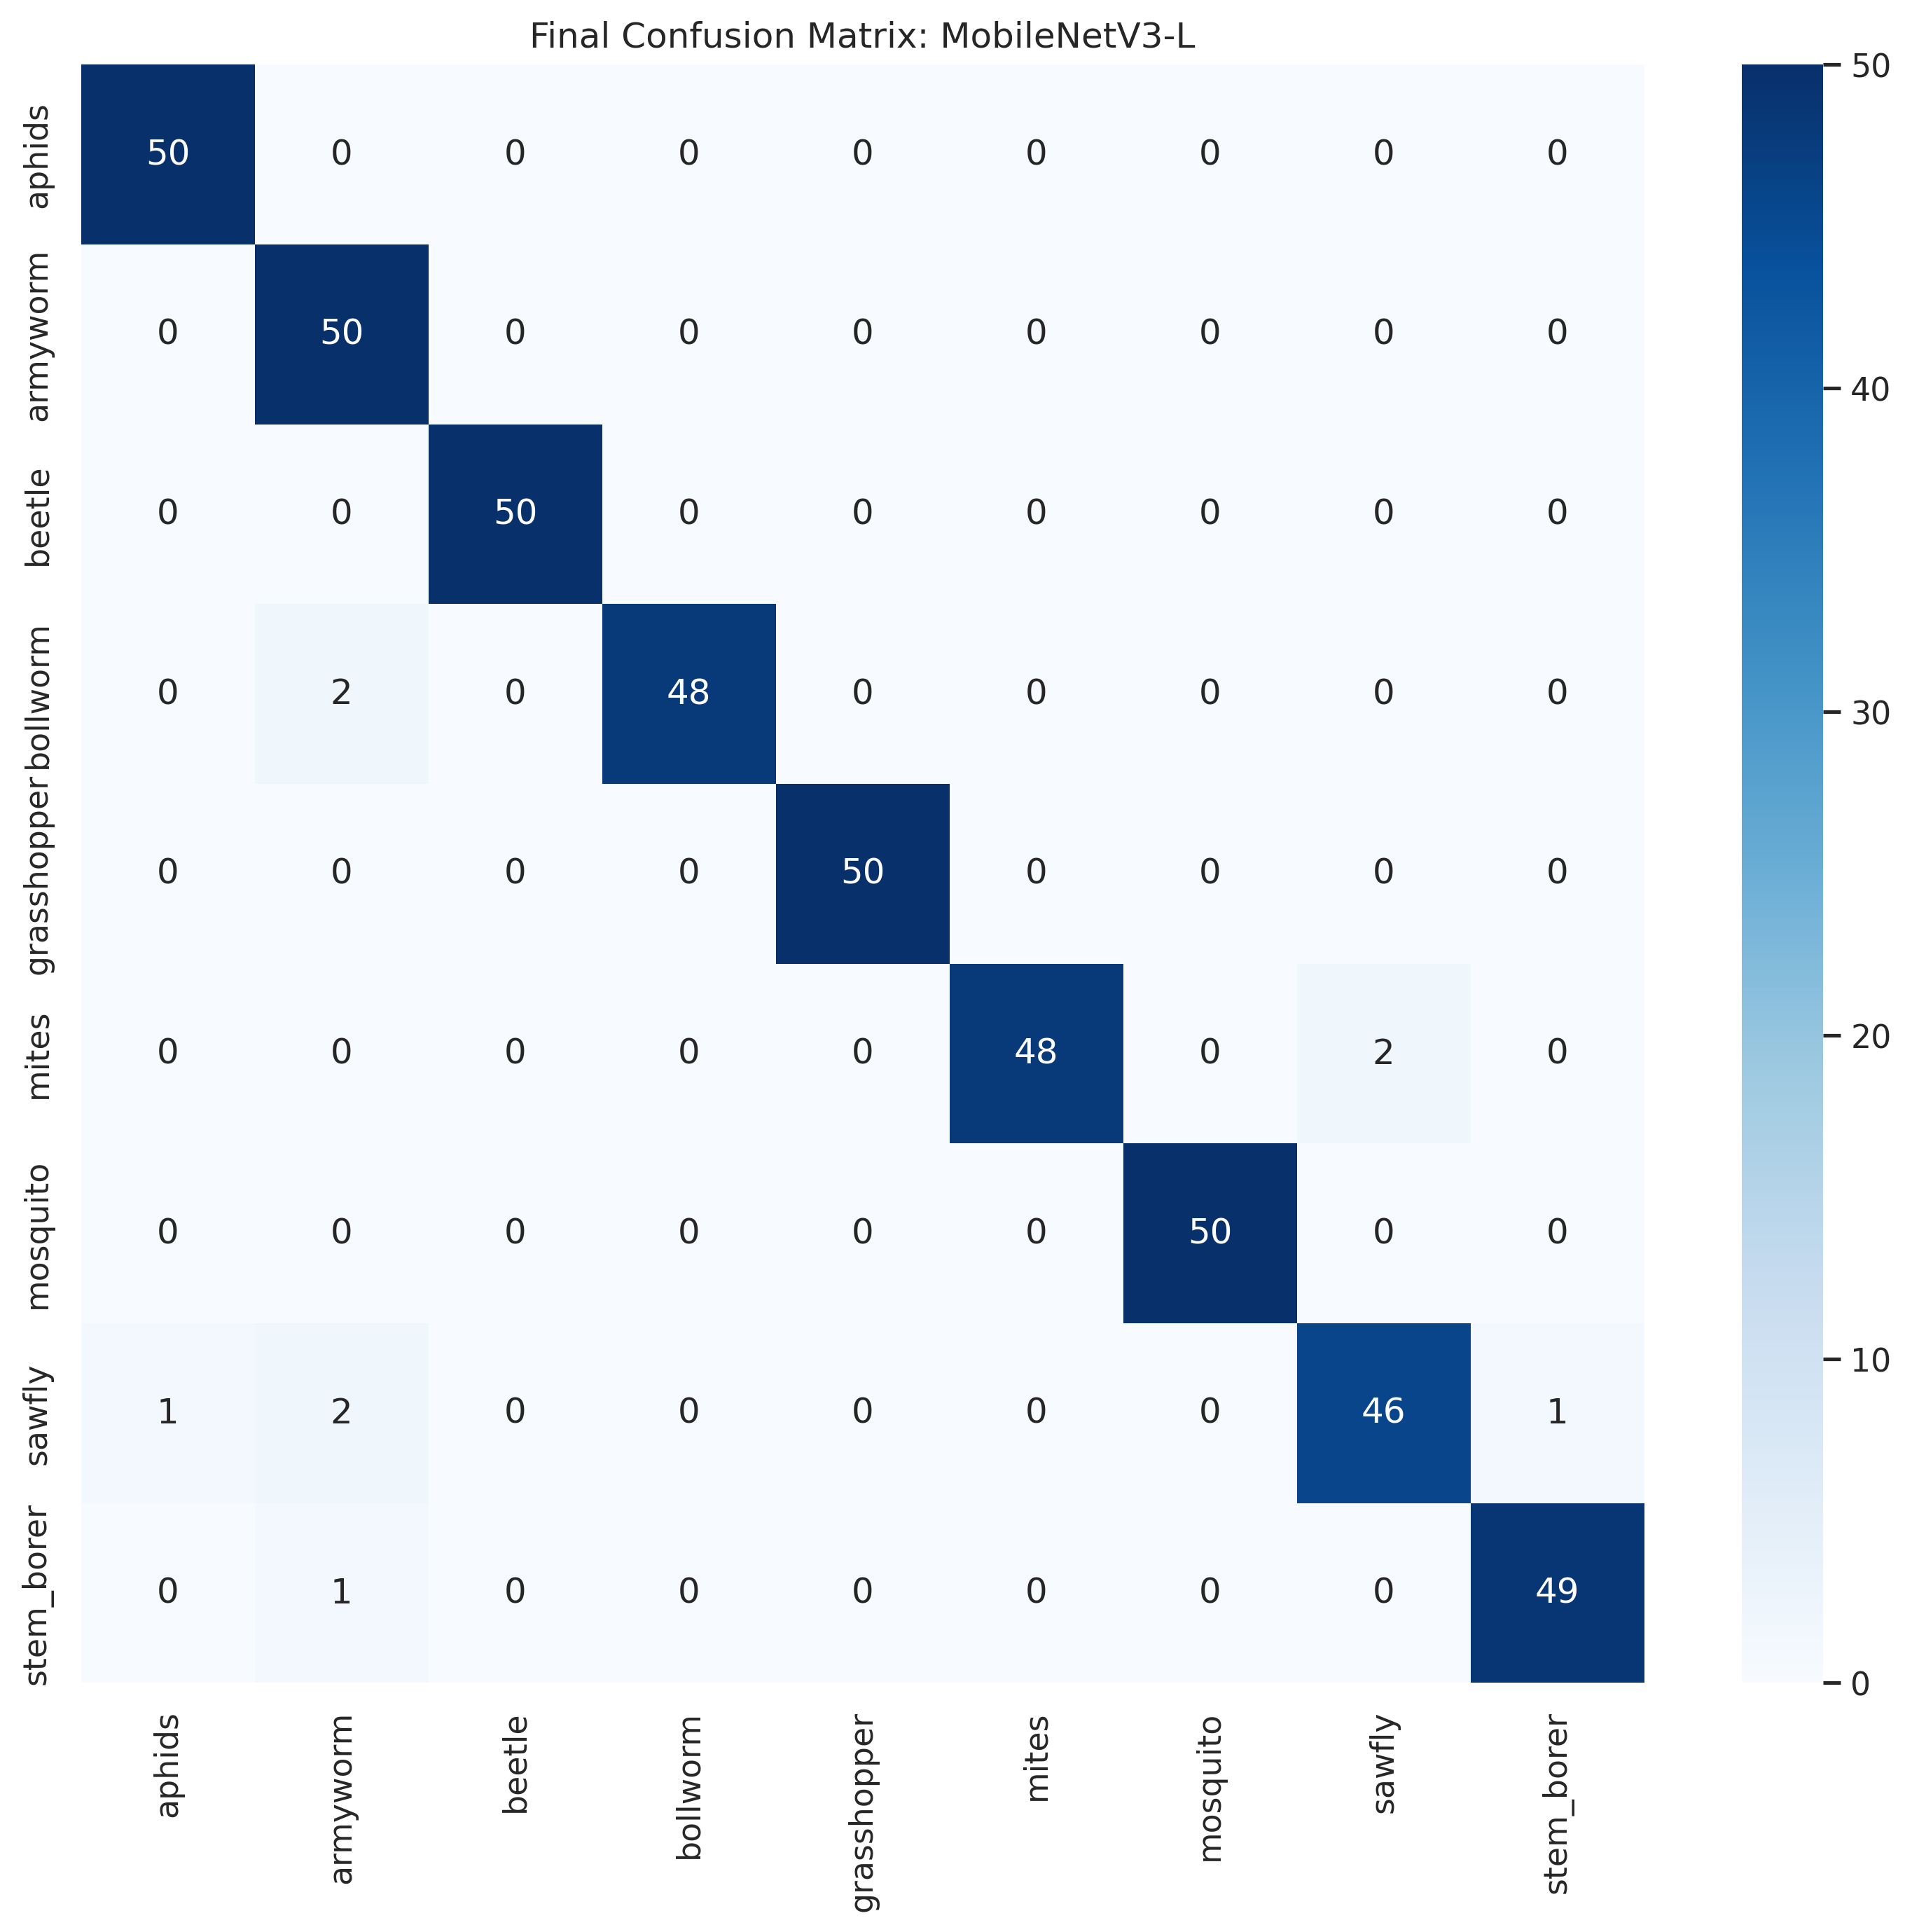

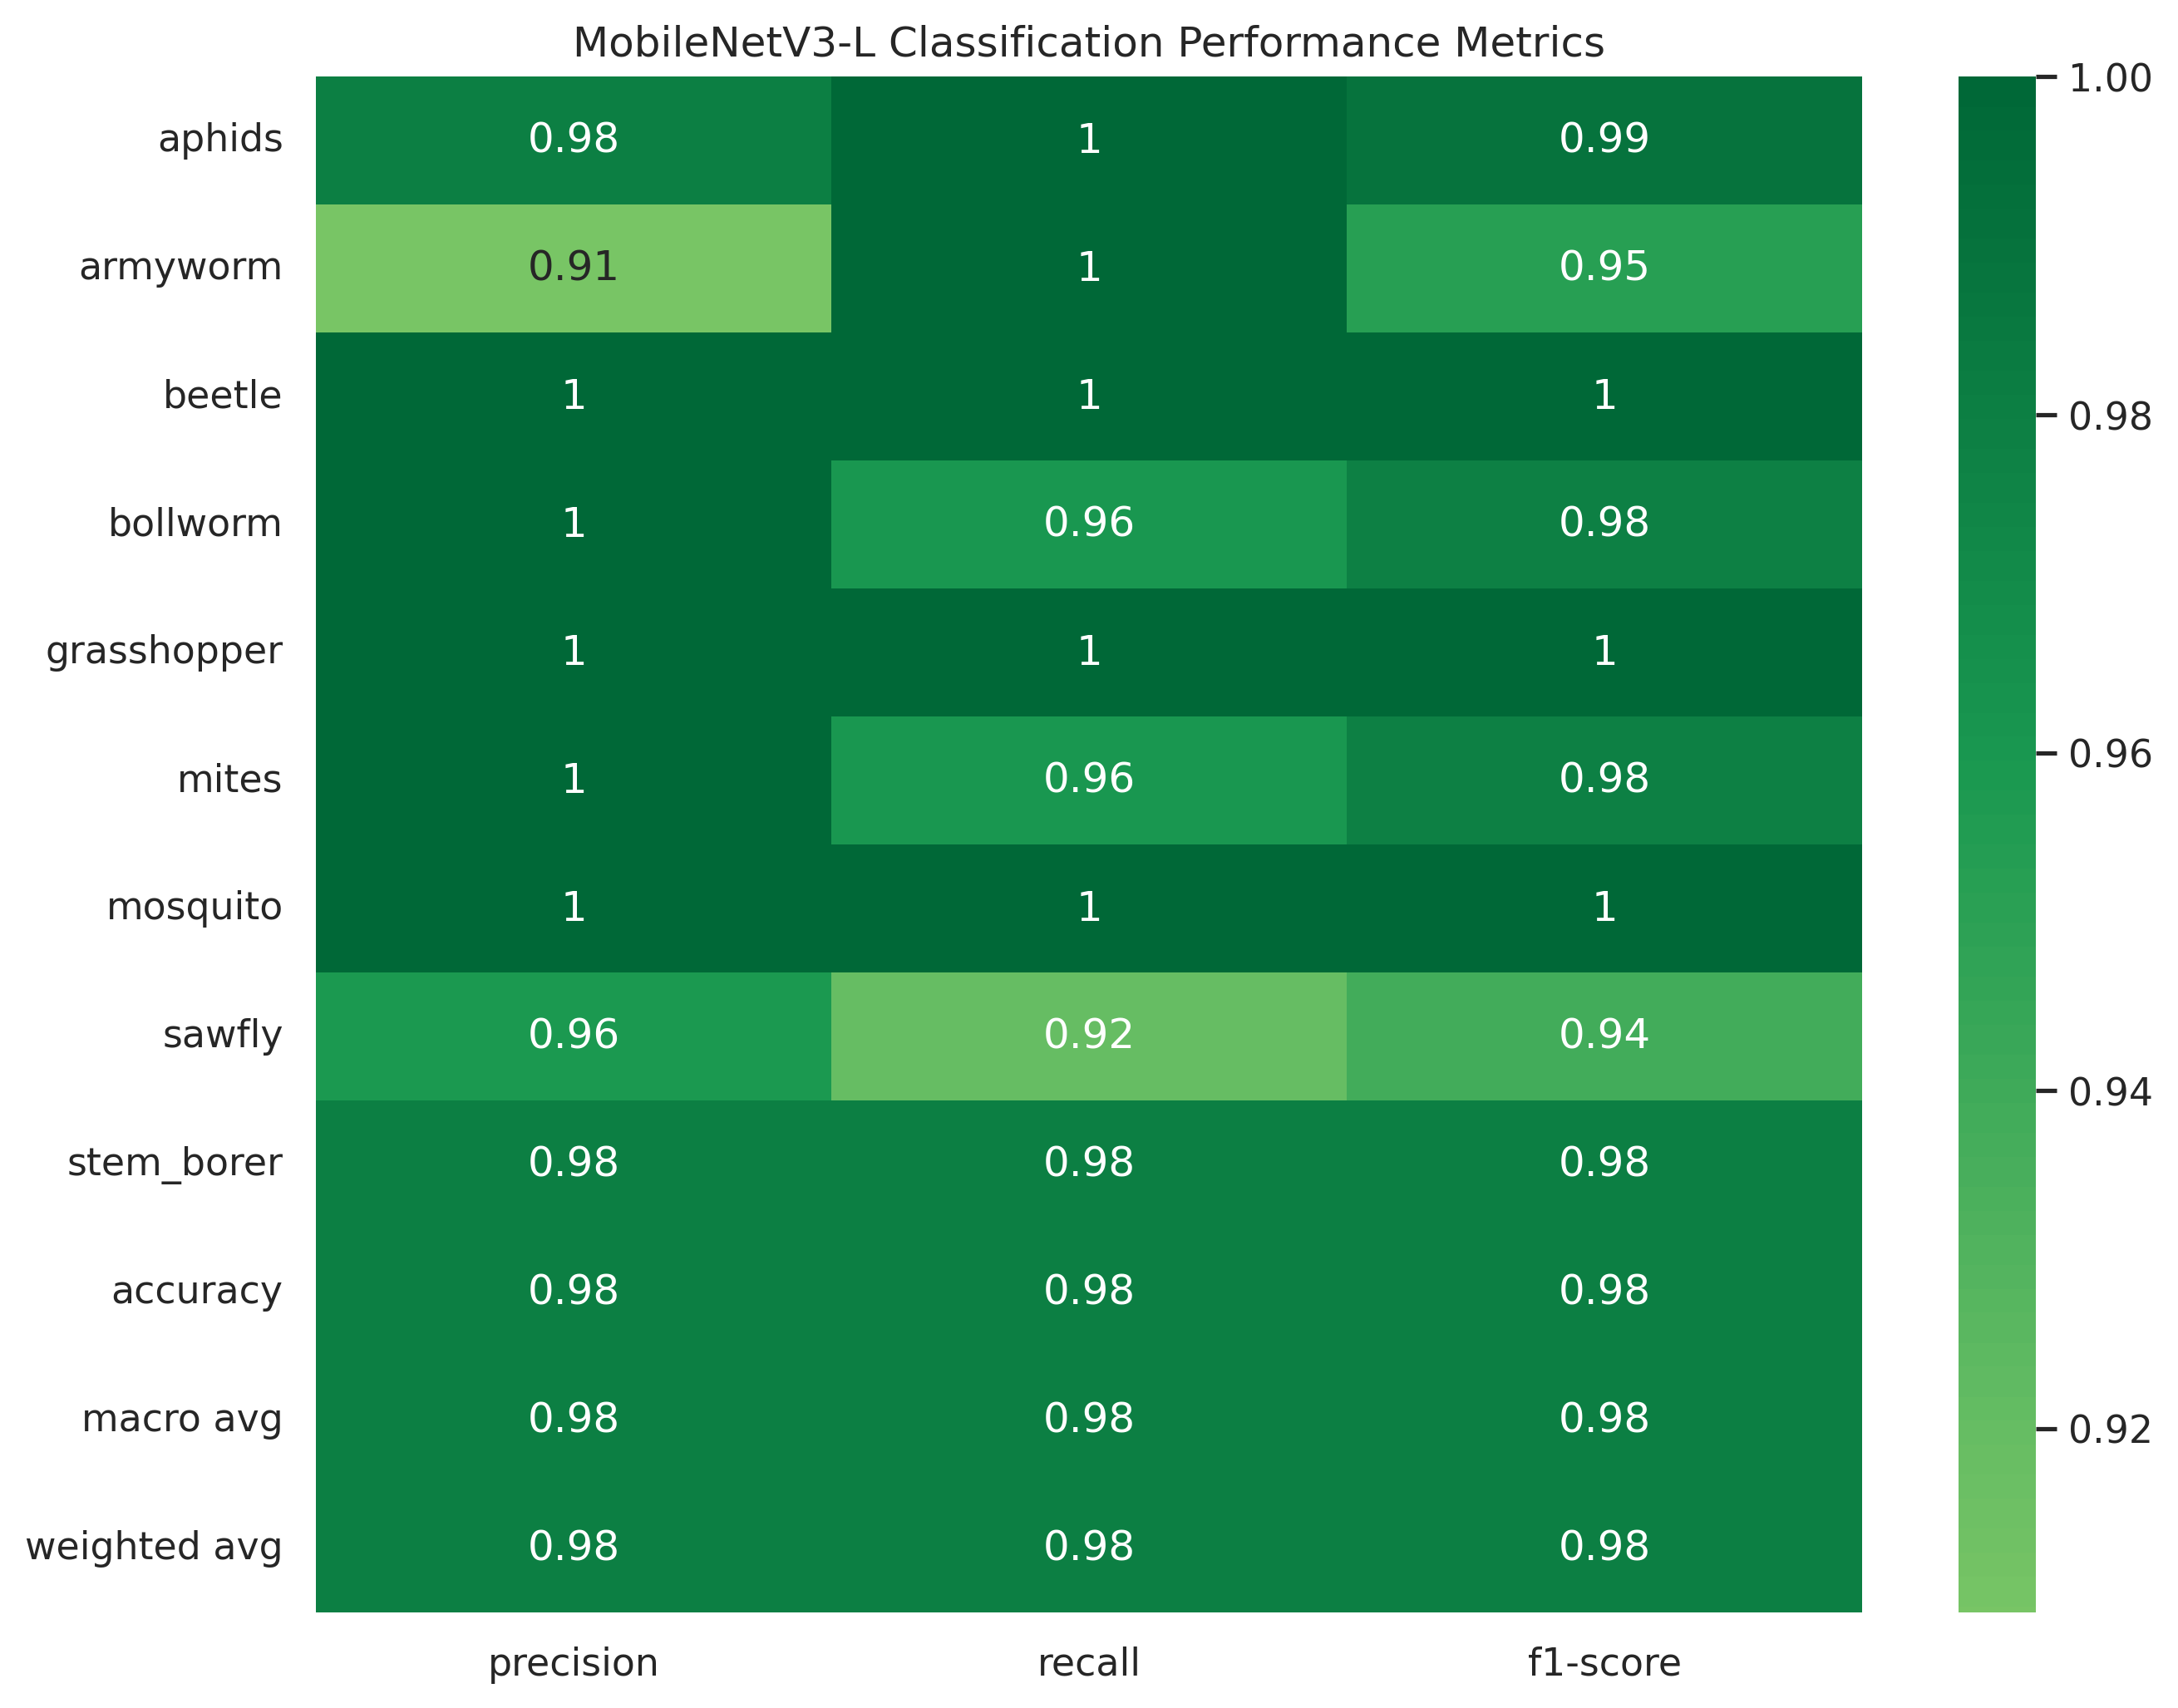

In [1]:
import os
import time
import copy
import gc
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report

# memory and hardware setup
gc.collect()
torch.cuda.empty_cache()
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
torch.backends.cudnn.benchmark = True 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# paths for simranvolunesia/pest-dataset
train_dir = '/kaggle/input/datasets/simranvolunesia/pest-dataset/pest/train'
val_dir = '/kaggle/input/datasets/simranvolunesia/pest-dataset/pest/test'

# edge-optimized settings
img_size = 224 
batch_size = 32
epochs = 25
patience = 5

class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

# augmentation strategy
train_tf = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.1, 0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_tf = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder(train_dir, train_tf)
val_data = datasets.ImageFolder(val_dir, val_tf)
classes = train_data.classes

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# init MobileNetV3-Large
model = models.mobilenet_v3_large(weights='DEFAULT')
in_features = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(in_features, len(classes))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
scaler = torch.amp.GradScaler('cuda')
stopper = EarlyStopping(patience=patience)

history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}
best_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

print(f"Finalizing MobileNetV3-L for {len(classes)} classes...")

for epoch in range(epochs):
    start_t = time.time()
    
    # training
    model.train()
    t_loss, t_correct, t_total = 0.0, 0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            out = model(imgs)
            loss = criterion(out, lbls)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        t_loss += loss.item() * imgs.size(0)
        _, p = torch.max(out, 1)
        t_total += lbls.size(0)
        t_correct += (p == lbls).sum().item()

    # validation
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            with torch.amp.autocast('cuda'):
                out = model(imgs)
                loss = criterion(out, lbls)
            v_loss += loss.item() * imgs.size(0)
            _, p = torch.max(out, 1)
            v_total += lbls.size(0)
            v_correct += (p == lbls).sum().item()

    epoch_loss = v_loss / v_total
    epoch_acc = v_correct / v_total
    
    history['train_acc'].append(t_correct / t_total)
    history['val_acc'].append(epoch_acc)
    history['train_loss'].append(t_loss / t_total)
    history['val_loss'].append(epoch_loss)
    
    scheduler.step(epoch_loss)
    print(f"Epoch {epoch+1:02d} | Val Acc: {epoch_acc*100:.2f}% | Val Loss: {epoch_loss:.4f} | Time: {time.time()-start_t:.0f}s")

    if epoch_acc > best_acc:
        best_acc = epoch_acc
        best_model_wts = copy.deepcopy(model.state_dict())
    
    stopper(epoch_loss)
    if stopper.early_stop:
        print("Early stopping triggered.")
        break

# save best model
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), '/kaggle/working/final_mobilenet_pest.pth')

# --- VISUALIZATIONS FOR PAPER ---
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 300

# 1. Training Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.plot(history['train_acc'], label='Training Accuracy', marker='o')
ax1.plot(history['val_acc'], label='Validation Accuracy', marker='s')
ax1.set_title('MobileNetV3 Accuracy Curves')
ax1.legend()

ax2.plot(history['train_loss'], label='Training Loss', marker='o')
ax2.plot(history['val_loss'], label='Validation Loss', marker='s')
ax2.set_title('MobileNetV3 Loss Curves')
ax2.legend()
plt.savefig('/kaggle/working/mobilenet_curves.png')

# 2. Confusion Matrix
all_preds, all_lbls = [], []
model.eval()
with torch.no_grad():
    for imgs, lbls in val_loader:
        imgs = imgs.to(device)
        out = model(imgs)
        _, p = torch.max(out, 1)
        all_preds.extend(p.cpu().numpy())
        all_lbls.extend(lbls.numpy())

cm = confusion_matrix(all_lbls, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Final Confusion Matrix: MobileNetV3-L')
plt.savefig('/kaggle/working/mobilenet_cm.png')

# 3. Detailed Report
report = classification_report(all_lbls, all_preds, target_names=classes, output_dict=True)
report_df = pd.DataFrame(report).iloc[:-1, :].T
plt.figure(figsize=(10, 8))
sns.heatmap(report_df, annot=True, cmap='RdYlGn', center=0.8)
plt.title('MobileNetV3-L Classification Performance Metrics')
plt.savefig('/kaggle/working/mobilenet_metrics_heatmap.png')

print("All research artifacts saved to /kaggle/working/")